In [289]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np


In [290]:
df=pd.read_csv('/content/karachi_properties_handle_missing_value-2.csv')

In [291]:
df.shape

(20331, 28)

In [292]:
completion_year_original = df["completion_year"].copy()
imputed_mask = completion_year_original.isna()

In [293]:
completion_year_original

,completion_year
0,2025.0
1,NaN
2,NaN
3,NaN
4,NaN
...,...
20326,NaN
20327,NaN
20328,2025.0
20329,NaN


In [294]:
mice_cols = [
    "completion_year",
    "area",
    "bedrooms",
    "bathrooms",
    "kitchen",
    "floor",
    "total_floors",
    "parking_score",
    "elevator",
    "servant_quarters",
    "electricity_backup",
    "furnished",
    "location_score",
    "sub_location_score",
    "area_per_bedroom"
]

In [295]:
mice_df=df[mice_cols].copy()

In [296]:
for col in mice_cols:
    mice_df[col] = pd.to_numeric(
        mice_df[col],
        errors="coerce"
    )

In [297]:
mice_df.shape

(20331, 15)

In [298]:
imputer=IterativeImputer(
    estimator=RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
),
max_iter=10,
random_state=42,
initial_strategy='median',
min_value=1950,
max_value=2033
)

In [299]:
imputed_array=imputer.fit_transform(mice_df)

In [300]:
imputed_df=pd.DataFrame(imputed_array,columns=mice_cols,index=df.index)

In [301]:
imputed_df['completion_year']=( imputed_df['completion_year'].round().astype("Int64"))

In [302]:
df.loc[df['completion_year'].isna(),'completion_year']=(imputed_df.loc[df['completion_year'].isna(),"completion_year"])

In [303]:
df['completion_year'].describe()

,completion_year
count,20331.000000
mean,2020.320053
std,6.337796
min,1918.000000
25%,2018.000000
50%,2022.000000
75%,2025.000000
max,2033.000000


In [304]:
df['age']=2026-df['completion_year']

In [305]:
df['age'].describe()

,age
count,20331.000000
mean,5.679947
std,6.337796
min,-7.000000
25%,1.000000
50%,4.000000
75%,8.000000
max,108.000000


In [306]:
imputed_years = df.loc[imputed_mask, "completion_year"]
original_years = df.loc[~imputed_mask, "completion_year"]

In [307]:
print(
    imputed_years
    .value_counts()
    .sort_index()
)

completion_year
1988.0       1
1989.0       1
1997.0       2
1998.0       1
1999.0       8
2000.0       3
2001.0       4
2002.0      13
2003.0      10
2004.0      24
2005.0      23
2006.0      34
2007.0      76
2008.0      81
2009.0     110
2010.0     113
2011.0     129
2012.0     219
2013.0     164
2014.0     219
2015.0     287
2016.0     363
2017.0     476
2018.0     610
2019.0     805
2020.0     890
2021.0    1115
2022.0    1068
2023.0    1077
2024.0     910
2025.0     501
2026.0     163
2027.0      48
2028.0      22
2029.0       3
Name: count, dtype: int64


In [308]:
print("Original known:")
print(original_years.value_counts().sort_index())

print("\nMICE imputed:")
print(imputed_years.value_counts().sort_index())

Original known:
completion_year
1918.0       1
1960.0       1
1965.0       1
1968.0       1
1970.0       4
1972.0       1
1975.0       1
1976.0       1
1979.0       1
1980.0       7
1985.0      10
1988.0       6
1989.0       3
1990.0      63
1992.0      11
1993.0       4
1994.0       3
1995.0      20
1996.0      15
1997.0       4
1998.0       7
1999.0      27
2000.0     294
2001.0      21
2002.0      33
2003.0      17
2004.0      14
2005.0     120
2006.0      25
2007.0      25
2008.0      73
2009.0      35
2010.0     250
2011.0      40
2012.0     111
2013.0      56
2014.0      75
2015.0     353
2016.0     137
2017.0     137
2018.0     334
2019.0     263
2020.0     606
2021.0     401
2022.0     639
2023.0     780
2024.0    1297
2025.0    1974
2026.0    1863
2027.0     117
2028.0     201
2029.0     105
2030.0     111
2031.0      41
2032.0      14
2033.0       4
Name: count, dtype: int64

MICE imputed:
completion_year
1988.0       1
1989.0       1
1997.0       2
1998.0       1
1999.0     

In [309]:
known_mask = completion_year_original.notna()

known_df = df.loc[known_mask].copy()

print("Known completion years:", len(known_df))

Known completion years: 10758


In [310]:
df.loc[
    (df["completion_year"] < 1980) |
    (df["completion_year"] > 2026),
    ["location", "sub_location", "completion_year", "property_type", "area", "price_crore"]
].sort_values("completion_year").value_counts()

location              sub_location               completion_year  property_type  area    price_crore
Scheme 33             Sector 29                  2031.0           flat           909.0   0.95           7
Gulshan-e-Iqbal Town  Gulshan-e-Iqbal Block 10A  2028.0           flat           2133.0  3.50           4
Clifton               Clifton Block 9            2029.0           flat           2223.0  6.25           3
DHA Defence           Phase 8                    2030.0           flat           864.0   3.45           3
                                                                                 900.0   3.58           3
                                                                                                       ..
                                                 2028.0           flat           2448.0  9.50           1
                                                                                         10.55          1
                                                                                 2493.0  10.50          1
                                                                                 2502.0  9.75           1
                                                                                 2358.0  11.60          1
Name: count, Length: 618, dtype: int64

In [311]:



df["completion_year"].value_counts().sort_index()


,count
completion_year,
1918.0,1
1960.0,1
1965.0,1
1968.0,1
1970.0,4
1972.0,1
1975.0,1
1976.0,1
1979.0,1


In [312]:
df[df["completion_year"] < 1980][
    ["location", "sub_location", "completion_year",
     "property_type", "area", "price_crore"]
].sort_values("completion_year")

,location,sub_location,completion_year,property_type,area,price_crore
11194,Jamshed Town,Smchs - Sindhi Muslim Society,1918.0,house,1935.0,12.00
11857,North Nazimabad,North Nazimabad Block A,1960.0,house,5400.0,13.00
10946,Jamshed Town,Pechs,1965.0,house,6750.0,21.00
16239,Federal B Area,Federal B Area Block 9,1968.0,house,2160.0,5.50
13628,North Nazimabad,North Nazimabad Block J,1970.0,house,1800.0,4.15
19762,Federal B Area,Federal B Area Block 19,1970.0,house,1080.0,2.18
17180,DHA Defence,Phase 2,1970.0,house,18000.0,42.00
1472,Federal B Area,Federal B Area Block 20,1970.0,house,1080.0,2.10
11476,Gulshan-e-Iqbal Town,Gulshan-e-Iqbal Town_Unspecified,1972.0,house,11052.0,32.00
7470,DHA Defence,Phase 5,1975.0,house,9000.0,30.00


In [313]:
original_missing_mask = completion_year_original.isna()

imputed_years = df.loc[
    original_missing_mask,
    "completion_year"
]

imputed_years.value_counts().sort_index()

,count
completion_year,
1988.0,1
1989.0,1
1997.0,2
1998.0,1
1999.0,8
2000.0,3
2001.0,4
2002.0,13
2003.0,10


In [ ]:
CURRENT_YEAR = 2026


df["property_age"] = CURRENT_YEAR - df["completion_year"]

# Group properties by age so the model can use a simple age category.
def age_category(age):
    if pd.isna(age):
        return np.nan
    elif age < 0:
        return "Under Construction"
    elif age == 0:
        return "New"
    elif age <= 5:
        return "Relatively New"
    elif age <= 10:
        return "Moderately Old"
    else:
        return "Old"

df["age_category"] = df["property_age"].apply(age_category)

# Check how many properties fall into each age category.
print(df["age_category"].value_counts(dropna=False))

age_category
Relatively New        9762
Moderately Old        4621
Old                   3256
New                   2026
Under Construction     666
Name: count, dtype: int64


In [315]:
CURRENT_YEAR = 2026


completion_year_original["property_age"] = CURRENT_YEAR - completion_year_original
def age_category(age):
    if pd.isna(age):
        return np.nan
    elif age < 0:
        return "Under Construction"
    elif age == 0:
        return "New"
    elif age <= 5:
        return "Relatively New"
    elif age <= 10:
        return "Moderately Old"
    else:
        return "Old"

test = completion_year_original["property_age"].apply(age_category)
print(test.value_counts(dropna=False))

completion_year
NaN                   9573
Relatively New        5091
New                   1863
Old                   1734
Moderately Old        1477
Under Construction     593
Name: count, dtype: int64


In [316]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20331 entries, 0 to 20330
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   property_name       20331 non-null  object 
 1   address             20331 non-null  object 
 2   location            20331 non-null  object 
 3   sub_location        20331 non-null  object 
 4   price               20331 non-null  float64
 5   price_crore         20331 non-null  float64
 6   price_per_sqft      20331 non-null  float64
 7   area                20331 non-null  float64
 8   bedrooms            20331 non-null  int64  
 9   bathrooms           20331 non-null  int64  
 10  kitchen             20331 non-null  float64
 11  floor               3982 non-null   float64
 12  total_floors        9517 non-null   float64
 13  parking             20331 non-null  float64
 14  elevator            20331 non-null  int64  
 15  servant_quarters    20331 non-null  float64
 16  elec

In [317]:
mice_cols = [
    "area",
    "bedrooms",
    "bathrooms",
    "floor",
    "location_score",
    "sub_location_score",
    "completion_year"
]

target = "total_floors"

In [318]:
mice_df=df[mice_cols].copy()

In [319]:
df['total_floors'].value_counts()

,count
total_floors,
2.0,3447
3.0,921
1.0,885
4.0,760
5.0,338
12.0,311
10.0,283
11.0,246
7.0,175


In [320]:
mice_data=df[mice_cols + ['total_floors']].copy()

known=mice_data[mice_data[target].notna()].copy()

print("Known total_floors:", len(known))
print("Missing total_floors:", mice_data[target].isna().sum())


Known total_floors: 9517
Missing total_floors: 10814


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error


# Convert flat and house labels into numeric values.
df["property_type_encoded"] = (
    df["property_type"]
    .astype(str)
    .str.lower()
    .map({
        "flat": 0,
        "house": 1
    })
)


# Select the columns used to estimate total floors.
features = [
    "area",
    "bedrooms",
    "bathrooms",
    "floor",
    "location_score",
    "sub_location_score",
    "completion_year",
    "property_type_encoded"
]

target = "total_floors"

features = [col for col in features if col in df.columns]


# Keep only records where the actual total-floor value is available.
known = df[
    features + [target]
].dropna(subset=[target]).copy()


# Split the known records into training and test sets.
train_known, test_known = train_test_split(
    known,
    test_size=0.20,
    random_state=42
)

train_data = train_known.copy()
test_data = test_known.copy()


# Hide the test values so the imputer can be evaluated fairly.
test_data[target] = np.nan

validation_data = pd.concat(
    [train_data, test_data],
    axis=0
)


# Configure a random forest to serve as the MICE estimator.
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

imputer = IterativeImputer(
    estimator=rf,
    max_iter=10,
    random_state=42
)


# Run the iterative imputation process.
imputed_array = imputer.fit_transform(
    validation_data
)

imputed_df = pd.DataFrame(
    imputed_array,
    columns=validation_data.columns,
    index=validation_data.index
)


# Compare the known test values with the imputed values.
actual = test_known[target]

predicted = imputed_df.loc[
    test_known.index,
    target
]


# Calculate the mean absolute error before rounding.
mae = mean_absolute_error(
    actual,
    predicted
)

print("===================================")
print("MICE VALIDATION WITH PROPERTY TYPE")
print("===================================")

print(f"MICE MAE: {mae:.3f} floors")


# Compare raw prediction errors for smaller and taller buildings.
validation_results = pd.DataFrame({
    "actual": actual,
    "predicted": predicted
})

validation_results["error"] = (
    validation_results["actual"] -
    validation_results["predicted"]
).abs()


print(
    "\nRaw ≤5 floors MAE:",
    validation_results[
        validation_results["actual"] <= 5
    ]["error"].mean()
)

print(
    "Raw >5 floors MAE:",
    validation_results[
        validation_results["actual"] > 5
    ]["error"].mean()
)


# Round the predictions and calculate the rounded error.
rounded_predicted = predicted.round()

rounded_mae = mean_absolute_error(
    actual,
    rounded_predicted
)

print("\nRaw MAE:", mae)
print("Rounded MAE:", rounded_mae)


# Compare the rounded errors for smaller and taller buildings.
rounded_results = pd.DataFrame({
    "actual": actual,
    "predicted": rounded_predicted
})

rounded_results["error"] = (
    rounded_results["actual"] -
    rounded_results["predicted"]
).abs()


print(
    "\nRounded ≤5 floors MAE:",
    rounded_results[
        rounded_results["actual"] <= 5
    ]["error"].mean()
)

print(
    "Rounded >5 floors MAE:",
    rounded_results[
        rounded_results["actual"] > 5
    ]["error"].mean()
)

MICE VALIDATION WITH PROPERTY TYPE
MICE MAE: 2.331 floors

Raw ≤5 floors MAE: 1.2207620178712817
Raw >5 floors MAE: 4.517908884926826

Raw MAE: 2.33077837384954
Rounded MAE: 2.3009453781512605

Rounded ≤5 floors MAE: 1.1884402216943786
Rounded >5 floors MAE: 4.492979719188767


In [322]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20331 entries, 0 to 20330
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   property_name          20331 non-null  object 
 1   address                20331 non-null  object 
 2   location               20331 non-null  object 
 3   sub_location           20331 non-null  object 
 4   price                  20331 non-null  float64
 5   price_crore            20331 non-null  float64
 6   price_per_sqft         20331 non-null  float64
 7   area                   20331 non-null  float64
 8   bedrooms               20331 non-null  int64  
 9   bathrooms              20331 non-null  int64  
 10  kitchen                20331 non-null  float64
 11  floor                  3982 non-null   float64
 12  total_floors           9517 non-null   float64
 13  parking                20331 non-null  float64
 14  elevator               20331 non-null  int64  
 15  se

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


# Convert the property type into a numeric feature.
df["property_type_encoded"] = (
    df["property_type"]
    .astype(str)
    .str.lower()
    .map({
        "flat": 0,
        "house": 1
    })
)


# Select the columns used by the MICE model.
features = [
    "area",
    "bedrooms",
    "bathrooms",
    "floor",
    "location_score",
    "sub_location_score",
    "completion_year",
    "property_type_encoded"
]

target = "total_floors"

# Keep only columns that are present in the dataframe.
features = [
    col for col in features
    if col in df.columns
]


# Keep records where total_floors is already known.
known = df[
    features + [target]
].dropna(subset=[target]).copy()


print("Known total_floors:", len(known))


# Split the known records into training and test sets.
train_known, test_known = train_test_split(
    known,
    test_size=0.20,
    random_state=42
)

train_data = train_known.copy()
test_data = test_known.copy()


# Save the actual test values for later comparison.
actual = test_data[target].copy()


# Hide the test values before running the imputer.
test_data[target] = np.nan


validation_data = pd.concat(
    [train_data, test_data],
    axis=0
)


# Configure the random forest used by the imputer.
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


# Configure the MICE imputer.
imputer = IterativeImputer(
    estimator=rf,
    max_iter=10,
    random_state=42
)


# Fit the imputer and transform the validation data.
imputed_array = imputer.fit_transform(
    validation_data
)

imputed_df = pd.DataFrame(
    imputed_array,
    columns=validation_data.columns,
    index=validation_data.index
)


# Extract the predicted total floors for the test records.
predicted = imputed_df.loc[
    test_known.index,
    target
]

rounded_predicted = (
    predicted
    .round()
    .clip(lower=1)
)


# Calculate both raw and rounded mean absolute error.
raw_mae = mean_absolute_error(
    actual,
    predicted
)

rounded_mae = mean_absolute_error(
    actual,
    rounded_predicted
)

print("\n===================================")
print("MICE VALIDATION WITH PROPERTY TYPE")
print("===================================")

print(
    f"Raw MAE: {raw_mae:.3f} floors"
)

print(
    f"Rounded MAE: {rounded_mae:.3f} floors"
)


# Build a table comparing actual and predicted floor counts.
results = pd.DataFrame({
    "actual": actual,
    "predicted": rounded_predicted
})

results["error"] = (
    results["actual"] -
    results["predicted"]
).abs()

# Compare errors for shorter and taller buildings.
low_floor_mae = results[
    results["actual"] <= 5
]["error"].mean()

high_floor_mae = results[
    results["actual"] > 5
]["error"].mean()


print(
    f"\n≤5 total floors MAE: {low_floor_mae:.3f}"
)

print(
    f">5 total floors MAE: {high_floor_mae:.3f}"
)


# Measure how often predictions are within one or two floors.
within_1 = (
    results["error"] <= 1
).mean()

within_2 = (
    results["error"] <= 2
).mean()


print(
    f"\nWithin ±1 floor: {within_1:.2%}"
)

print(
    f"Within ±2 floors: {within_2:.2%}"
)


# Display a sample of actual and predicted floor counts.
print("\n===================================")
print("ACTUAL VS PREDICTED TOTAL FLOORS")
print("===================================")

print(
    results.head(20)
)


# Display the predictions with the largest errors.
print("\n===================================")
print("WORST PREDICTIONS")
print("===================================")

print(
    results
    .sort_values(
        "error",
        ascending=False
    )
    .head(20)
)


# Show how frequently each absolute error occurs.
print("\n===================================")
print("ERROR DISTRIBUTION")
print("===================================")

print(
    results["error"]
    .value_counts()
    .sort_index()
)

Known total_floors: 9517

MICE VALIDATION WITH PROPERTY TYPE
Raw MAE: 2.331 floors
Rounded MAE: 2.301 floors

≤5 total floors MAE: 1.188
>5 total floors MAE: 4.493

Within ±1 floor: 67.49%
Within ±2 floors: 75.32%

ACTUAL VS PREDICTED TOTAL FLOORS
       actual  predicted  error
10290    15.0       20.0    5.0
3944      2.0        2.0    0.0
14338     3.0        4.0    1.0
18670     1.0        2.0    1.0
7123      2.0        1.0    1.0
19103     2.0        2.0    0.0
14147    16.0       17.0    1.0
1580      1.0        2.0    1.0
4810     11.0       12.0    1.0
4674     48.0       18.0   30.0
1157      2.0        1.0    1.0
11558     6.0       17.0   11.0
18554     3.0        1.0    2.0
4382      4.0        8.0    4.0
15904    15.0       29.0   14.0
18769     4.0       11.0    7.0
2088      3.0        1.0    2.0
2545     45.0       33.0   12.0
19311    20.0       20.0    0.0
2922      2.0        2.0    0.0

WORST PREDICTIONS
       actual  predicted  error
2395     82.0        9.0   73

In [ ]:
# Use MICE to fill the total_floors values that are actually missing.

# Define the model features and the value to impute.
features = [
    "area",
    "bedrooms",
    "bathrooms",
    "floor",
    "location_score",
    "sub_location_score",
    "completion_year",
    "property_type_encoded"
]

target = "total_floors"

# Keep only features that are available in the dataframe.
features = [
    col for col in features
    if col in df.columns
]


# Record which rows originally had a missing total_floors value.
missing_mask = df[target].isna()

print("Missing total_floors before MICE:",
      missing_mask.sum())


# Prepare the complete feature set for the imputer.
full_data = df[
    features + [target]
].copy()


# Configure the random forest used by MICE.
final_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


# Configure the final iterative imputer.
final_imputer = IterativeImputer(
    estimator=final_rf,
    max_iter=10,
    random_state=42
)


# Fit the imputer and transform the complete dataset.
imputed_array = final_imputer.fit_transform(
    full_data
)

imputed_df = pd.DataFrame(
    imputed_array,
    columns=full_data.columns,
    index=full_data.index
)


# Extract predictions only for rows that were originally missing.
imputed_total_floors = (
    imputed_df.loc[
        missing_mask,
        target
    ]
    .round()
    .clip(lower=1)
)


# Put the predictions back only where total_floors was missing.
df.loc[
    missing_mask,
    target
] = imputed_total_floors


# Apply the final rounding and lower bound to the whole column.
df[target] = (
    df[target]
    .round()
    .clip(lower=1)
)


# Check how many values remain missing and how many were imputed.
print("\n===================================")
print("FINAL TOTAL_FLOORS IMPUTATION")
print("===================================")

print(
    "Remaining missing:",
    df[target].isna().sum()
)

print(
    "Rows imputed:",
    missing_mask.sum()
)


# Keep a table of the predictions that were actually made.
imputed_results = pd.DataFrame({
    "index": imputed_total_floors.index,
    "property_type": df.loc[
        imputed_total_floors.index,
        "property_type"
    ].values,
    "predicted_total_floors":
        imputed_total_floors.values
})

print("\n===================================")
print("IMPUTED TOTAL_FLOORS")
print("===================================")

print(
    imputed_results.head(20)
)


# Summarize the imputed values for each property type.
print("\n===================================")
print("IMPUTED VALUES BY PROPERTY TYPE")
print("===================================")

print(
    imputed_results
    .groupby("property_type")[
        "predicted_total_floors"
    ]
    .describe()
)


# Display the final distribution of total-floor values.
print("\n===================================")
print("FINAL TOTAL_FLOORS DISTRIBUTION")
print("===================================")

print(
    df[target]
    .value_counts()
    .sort_index()
)

Missing total_floors before MICE: 10814

FINAL TOTAL_FLOORS IMPUTATION
Remaining missing: 0
Rows imputed: 10814

IMPUTED TOTAL_FLOORS
    index property_type  predicted_total_floors
0       1         house                     3.0
1       3          flat                    15.0
2       4          flat                    11.0
3       6          flat                    35.0
4       9          flat                     5.0
5      11         house                     2.0
6      12          flat                    18.0
7      14         house                     2.0
8      16         house                     2.0
9      18         house                     2.0
10     20          flat                     4.0
11     21         house                     3.0
12     23          flat                    20.0
13     24          flat                    12.0
14     27         house                     2.0
15     29         house                     3.0
16     31         house                     2.0
17

<Axes: xlabel='total_floors', ylabel='Density'>

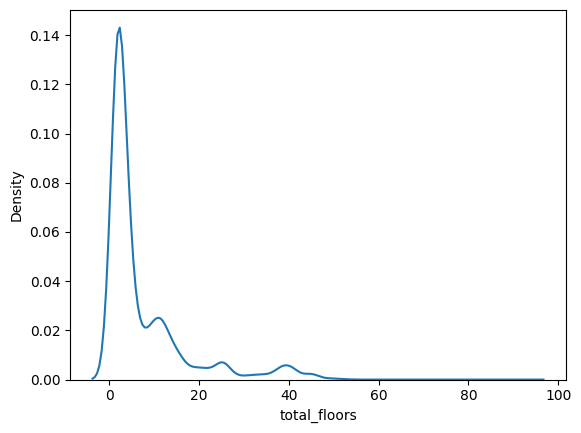

In [325]:
import seaborn as sns
sns.kdeplot(full_data['total_floors'])

<Axes: xlabel='total_floors', ylabel='Density'>

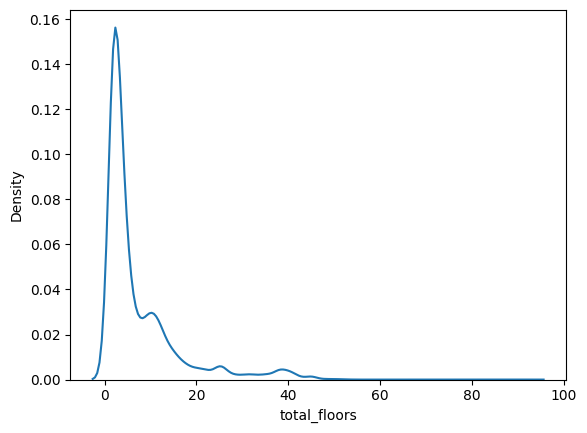

In [326]:
sns.kdeplot(df['total_floors'])

In [327]:
df['total_floors'].isnull().sum()

np.int64(0)

<Axes: xlabel='completion_year', ylabel='Density'>

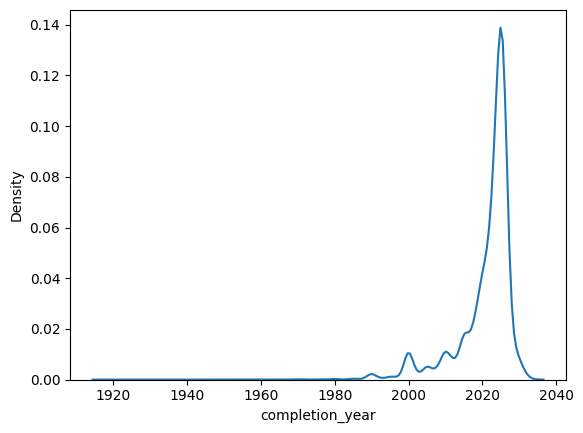

In [328]:
sns.kdeplot(known_df['completion_year'])


<Axes: xlabel='completion_year', ylabel='Density'>

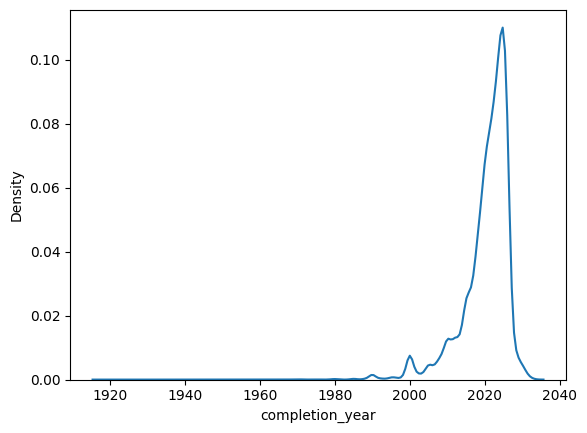

In [329]:
sns.kdeplot(df['completion_year'])


In [330]:
df['floor'].isnull().sum()

np.int64(16349)

In [331]:
df['property_type'].value_counts()

,count
property_type,
flat,10475
house,9856


In [332]:
print(
    df[df["floor"].notna()]
    .groupby("property_type")["floor"]
    .value_counts()
)

property_type  floor
flat           1.0      728
               2.0      616
               3.0      557
               4.0      415
               5.0      309
               6.0      215
               8.0      167
               7.0      158
               9.0      114
               10.0      96
               0.0       85
               11.0      69
               12.0      47
               15.0      45
               13.0      40
               14.0      35
               20.0      30
               18.0      26
               16.0      18
               19.0      16
               25.0      16
               17.0      15
               21.0      14
               24.0      13
               22.0      12
               26.0       9
               28.0       9
               23.0       8
               32.0       8
               30.0       6
               35.0       4
               29.0       3
               27.0       2
               31.0       2
               33.0       2

In [333]:
df[(df['property_type']=='house') & (df['floor'] > 0)][['property_name','floor','total_floors']]

,property_name,floor,total_floors
191,"ground rcc + 1st floor 2 room precast, 80 yard...",1.0,2.0
624,500 sq yards bungalow near hill park basement ...,1.0,3.0
1172,200 sq yard 3rd floor paint house 4 bed withou...,3.0,4.0
1848,ground+2 floor house block 12 gulistan e jauha...,2.0,3.0
2068,brand new house 240 square yard ground + 2 floor,2.0,3.0
2461,brand new luxury 120 sq yards ground +1 floor ...,1.0,2.0
3435,ground plus one 2nd floor 1 master bedroom att...,2.0,2.0
4166,zero metar three side corner ground plus two p...,3.0,3.0
4258,"120 yards, ground rcc and 2 bed dd in 1st floo...",1.0,2.0
4649,luxury brand new 120 square yards ground + 1 f...,1.0,2.0


In [334]:
df[(df['property_type']=='flat') & (df['floor'].notna())].shape

(3917, 30)

In [335]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20331 entries, 0 to 20330
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   property_name          20331 non-null  object 
 1   address                20331 non-null  object 
 2   location               20331 non-null  object 
 3   sub_location           20331 non-null  object 
 4   price                  20331 non-null  float64
 5   price_crore            20331 non-null  float64
 6   price_per_sqft         20331 non-null  float64
 7   area                   20331 non-null  float64
 8   bedrooms               20331 non-null  int64  
 9   bathrooms              20331 non-null  int64  
 10  kitchen                20331 non-null  float64
 11  floor                  3982 non-null   float64
 12  total_floors           20331 non-null  float64
 13  parking                20331 non-null  float64
 14  elevator               20331 non-null  int64  
 15  se

In [ ]:
features = [
    "area",
    "bedrooms",
    "bathrooms",
    "total_floors",
    "location_score",
    "sub_location_score",
    "completion_year"
]

target = "floor"


# Keep only features that are available in the dataframe.
features = [
    col for col in features
    if col in df.columns
]


# Restrict the validation data to flats.
flat_mask = (
    df["property_type"]
    .astype(str)
    .str.lower()
    .eq("flat")
)

known = df.loc[
    flat_mask,
    features + [target]
].dropna(subset=[target]).copy()


print("Known flat floors:", len(known))


# Split the known flat records into training and test sets.
train_known, test_known = train_test_split(
    known,
    test_size=0.20,
    random_state=42
)


train_data = train_known.copy()
test_data = test_known.copy()


# Hide the test floor values before running MICE.
test_data[target] = np.nan


validation_data = pd.concat(
    [train_data, test_data],
    axis=0
)


# Configure the random forest and iterative imputer.
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

imputer = IterativeImputer(
    estimator=rf,
    max_iter=10,
    random_state=42
)


# Run the imputer on the validation data.
imputed_array = imputer.fit_transform(
    validation_data
)

imputed_df = pd.DataFrame(
    imputed_array,
    columns=validation_data.columns,
    index=validation_data.index
)


# Compare the known test floors with the predictions.
actual = test_known[target]

predicted = imputed_df.loc[
    test_known.index,
    target
]


# Calculate the raw mean absolute error.
mae = mean_absolute_error(
    actual,
    predicted
)

print("\n===================================")
print("MICE FLOOR VALIDATION — FLATS ONLY")
print("===================================")

print(f"Raw MAE: {mae:.3f} floors")


# Round the predictions and keep them non-negative.
rounded_predicted = predicted.round()

rounded_predicted = rounded_predicted.clip(
    lower=0
)

rounded_mae = mean_absolute_error(
    actual,
    rounded_predicted
)

print(f"Rounded MAE: {rounded_mae:.3f} floors")


# Compare prediction errors for shorter and taller flats.
results = pd.DataFrame({
    "actual": actual,
    "predicted": rounded_predicted
})

results["error"] = (
    results["actual"] -
    results["predicted"]
).abs()


low_floor_mae = results[
    results["actual"] <= 5
]["error"].mean()


high_floor_mae = results[
    results["actual"] > 5
]["error"].mean()


print(
    f"\n≤5 floors MAE: {low_floor_mae:.3f}"
)

print(
    f">5 floors MAE: {high_floor_mae:.3f}"
)


# Measure how often predictions are within one or two floors.
within_1 = (
    results["error"] <= 1
).mean()

within_2 = (
    results["error"] <= 2
).mean()


print(
    f"\nWithin ±1 floor: {within_1:.2%}"
)

print(
    f"Within ±2 floors: {within_2:.2%}"
)


# Display a sample of the predictions.
print("\nSample predictions:")

print(
    results.head(20)
)

Known flat floors: 3917

MICE FLOOR VALIDATION — FLATS ONLY
Raw MAE: 2.601 floors
Rounded MAE: 2.588 floors

≤5 floors MAE: 1.950
>5 floors MAE: 4.033

Within ±1 floor: 49.36%
Within ±2 floors: 66.96%

Sample predictions:
       actual  predicted  error
1601      3.0        4.0    1.0
10692     5.0        1.0    4.0
4425     15.0        8.0    7.0
15036     6.0        7.0    1.0
10609    12.0       10.0    2.0
19169     2.0        2.0    0.0
18233     1.0        6.0    5.0
12094     1.0        2.0    1.0
9593      3.0        2.0    1.0
9243      1.0        1.0    0.0
8327      2.0        7.0    5.0
8957      1.0        3.0    2.0
10000     8.0        4.0    4.0
19052     3.0        3.0    0.0
14427     6.0       10.0    4.0
14177     2.0        2.0    0.0
5535      2.0        5.0    3.0
6952      4.0        5.0    1.0
95        1.0        1.0    0.0
8385      4.0        4.0    0.0


In [ ]:
# Create a category for the floor value.
df["floor_category"] = df["floor"].astype("string")

# Mark flats whose floor information is missing.
flat_mask = (
    df["property_type"]
    .astype(str)
    .str.lower()
    .eq("flat")
)

df.loc[
    flat_mask & df["floor"].isna(),
    "floor_category"
] = "Unknown"

# Floors do not apply to houses in this analysis.
house_mask = (
    df["property_type"]
    .astype(str)
    .str.lower()
    .eq("house")
)

df.loc[
    house_mask,
    "floor_category"
] = "Not_Applicable"


# Review the resulting floor categories.
print(df["floor_category"].value_counts(dropna=False))

floor_category
Not_Applicable    9856
Unknown           6558
1.0                728
2.0                616
3.0                557
4.0                415
5.0                309
6.0                215
8.0                167
7.0                158
9.0                114
10.0                96
0.0                 85
11.0                69
12.0                47
15.0                45
13.0                40
14.0                35
20.0                30
18.0                26
16.0                18
25.0                16
19.0                16
17.0                15
21.0                14
24.0                13
22.0                12
26.0                 9
28.0                 9
32.0                 8
23.0                 8
30.0                 6
35.0                 4
29.0                 3
33.0                 2
36.0                 2
31.0                 2
27.0                 2
34.0                 2
39.0                 1
38.0                 1
41.0                 1
40.0               

In [338]:
df[df['property_type']=='flat']['total_floors'].value_counts()

,count
total_floors,
4.0,1453
5.0,1098
10.0,708
6.0,638
11.0,578
12.0,577
9.0,548
7.0,545
8.0,474


In [339]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20331 entries, 0 to 20330
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   property_name          20331 non-null  object 
 1   address                20331 non-null  object 
 2   location               20331 non-null  object 
 3   sub_location           20331 non-null  object 
 4   price                  20331 non-null  float64
 5   price_crore            20331 non-null  float64
 6   price_per_sqft         20331 non-null  float64
 7   area                   20331 non-null  float64
 8   bedrooms               20331 non-null  int64  
 9   bathrooms              20331 non-null  int64  
 10  kitchen                20331 non-null  float64
 11  floor                  3982 non-null   float64
 12  total_floors           20331 non-null  float64
 13  parking                20331 non-null  float64
 14  elevator               20331 non-null  int64  
 15  se

In [344]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20331 entries, 0 to 20330
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   property_name          20331 non-null  object 
 1   address                20331 non-null  object 
 2   location               20331 non-null  object 
 3   sub_location           20331 non-null  object 
 4   price                  20331 non-null  float64
 5   price_crore            20331 non-null  float64
 6   price_per_sqft         20331 non-null  float64
 7   area                   20331 non-null  float64
 8   bedrooms               20331 non-null  int64  
 9   bathrooms              20331 non-null  int64  
 10  kitchen                20331 non-null  float64
 11  floor                  13773 non-null  object 
 12  total_floors           20331 non-null  float64
 13  parking                20331 non-null  float64
 14  elevator               20331 non-null  int64  
 15  se

In [341]:
df.loc[df['property_type'] == 'house', ['floor']]=np.nan

In [342]:
df.loc[df['property_type'] == 'house', ['floor']]='Not_applicable'

/tmp/ipykernel_5342/823858544.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Not_applicable' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df['property_type'] == 'house', ['floor']]='Not_applicable'


In [345]:
df.to_csv('karachi properties handle missing values 3.csv', index=False)